# BERTopic Model

In [2]:
!pip install bertopic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.9 MB/s eta 0:00:00


In [3]:
# reads:cleaned_articles.parquet
# writes new files: topic_assignments.parquet, topic_labels.csv

import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from google.colab import drive
import matplotlib.pyplot as plt

drive.mount('/content/drive')
path = '/content/drive/MyDrive/nlp_final_project/'

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Mounted at /content/drive


In [11]:
df = pd.read_parquet(path + 'cleaned_articles.parquet')
print(f"Loaded {len(df)} articles")

Loaded 196629 articles


In [12]:
# test on sample
df_sample = df.sample(10000, random_state=42)
docs_sample = df_sample['text_clean'].tolist()
docs_full = df['text_clean'].tolist()

In [5]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# reduce dimensionality
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)


# clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=570,
    min_samples=1,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# vectorizer
vectorizer_model = CountVectorizer(
    min_df=0.001,
    ngram_range=(1, 2),
    stop_words='english'
)

# bertopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=15,
    nr_topics='auto',
    calculate_probabilities=False,
    verbose=True
)

In [ ]:
# # embeddings (for reuse)
# sample_embeddings = embedding_model.encode(
#     docs_sample,
#     show_progress_bar=True,
#     batch_size=64
# )

# np.save(path + 'sample_embeddings.npy', sample_embeddings)

# sample_embeddings = np.load(path + 'sample_embeddings.npy')


In [6]:
# embeddings (for reuse)
# full_embeddings = embedding_model.encode(
#     docs_full,
#     show_progress_bar=True,
#     batch_size=64
# )

# np.save(path + 'full_embeddings.npy', full_embeddings)

full_embeddings = np.load(path + 'full_embeddings.npy')

In [ ]:
# # fit on sample
# topics_sample, probs_sample = topic_model.fit_transform(
#     docs_sample,
#     embeddings=sample_embeddings
# )

In [13]:
# fit on full
topics, probs = topic_model.fit_transform(
    docs_full,
    embeddings=full_embeddings
)

topic_model.save(path + 'bertopic_model')

2026-03-07 17:56:49,559 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-07 18:04:11,664 - BERTopic - Dimensionality - Completed ✓
2026-03-07 18:04:11,669 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 18:04:24,214 - BERTopic - Cluster - Completed ✓
2026-03-07 18:04:24,215 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-07 18:13:41,642 - BERTopic - Representation - Completed ✓
2026-03-07 18:13:42,991 - BERTopic - Topic reduction - Reducing number of topics
2026-03-07 18:13:43,061 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-07 18:23:11,335 - BERTopic - Representation - Completed ✓
2026-03-07 18:23:12,918 - BERTopic - Topic reduction - Reduced number of topics from 63 to 34
2026-03-07 18:23:56,442 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mod

In [ ]:
# sample_topic_info = topic_model.get_topic_info()
# print(f"Number of topics found: {len(sample_topic_info) - 1}")
# sample_topic_info.head(20)

Number of topics found: 8


Topic  Count                                    Name  \
0     -1   3078                     -1_ai_news_new_data   
1      0   3550                    0_ai_news_share_data   
2      1   2064                     1_ai_news_gray_2023   
3      2    403                    2_px 300_px_jpeg_300   
4      3    251             3_health_ai_healthcare_news   
5      4    214   4_services_products_ment_overviewview   
6      5    190  5_newswires_presswire_ai_ein presswire   
7      6    128                  6_price_rate_market_ai   
8      7    122                   7_music_ai_voice_news   

                                                                                               Representation  \
0                              [ai, news, new, data, 2023, technology, business, 2024, intelligence, company]   
1                                     [ai, news, share, data, new, market, technology, business, 2025, price]   
2                                              [ai, news, gray, 2023, new, media, ago, said, weather, public]   
3   [px 300, px, jpeg, 300, rawpixel, generated image, ai generated, generated, image, rawpixel termsprivacy]   
4                                [health, ai, healthcare, news, medical, care, research, new, market, cancer]   
5  [services, products, ment, overviewview, consumer, general, technology, entertain ment, entertain, policy]   
6                   [newswires, presswire, ai, ein presswire, ein, new, releases, south, north, distribution]   
7                                    [price, rate, market, ai, trading, crypto, mexc, rates, buy, conversion]   
8                                          [music, ai, voice, news, new, song, artists, songs, spotify, 2023]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [20]:
topic_info = topic_model.get_topic_info()
print(f"Number of topics found: {len(topic_info) - 1}")
topic_info

Output hidden; open in https://colab.research.google.com to view.

In [16]:
topic_model.visualize_topics()

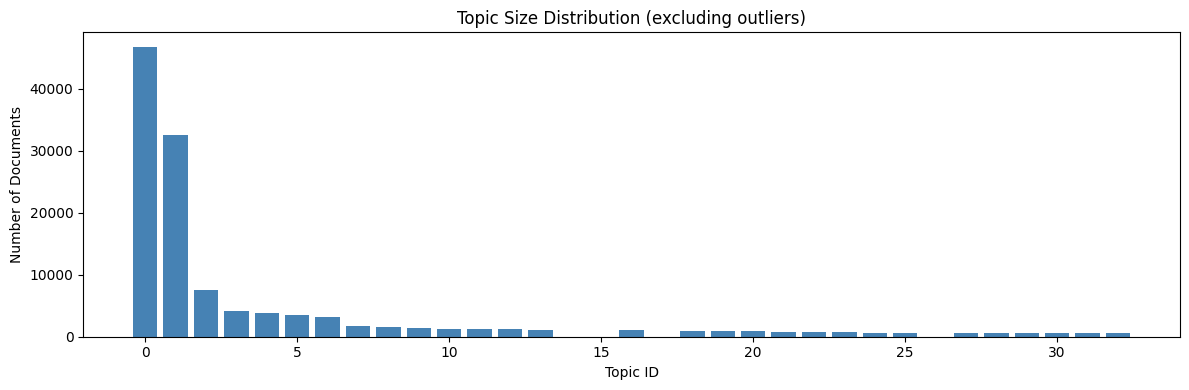

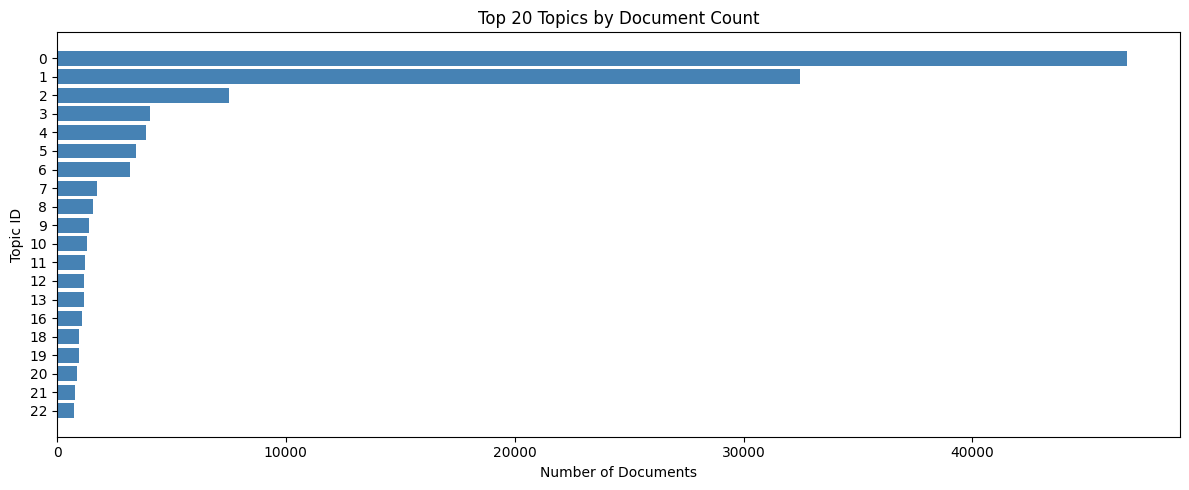

Total documents:     196629
Topics found:        29
Outlier documents:   70718 (36.0%)
Avg docs per topic:  4208
Largest topic:       46736 docs
Smallest topic:      572 docs


In [27]:
import matplotlib.pyplot as plt
import numpy as np

exclude_topics = {-1,14,15,17,26}
topic_info_clean = (
    topic_info[~topic_info['Topic'].isin(exclude_topics)]
    .reset_index(drop = True)
)

# topic distribution
plt.figure(figsize=(12, 4))
plt.bar(topic_info_clean['Topic'], topic_info_clean['Count'], color='steelblue')
plt.title('Topic Size Distribution (excluding outliers)')
plt.xlabel('Topic ID')
plt.ylabel('Number of Documents')
plt.tight_layout()
plt.show()

# top 20
top_topics = topic_info_clean.nlargest(20, 'Count')
plt.figure(figsize=(12, 5))
plt.barh(top_topics['Topic'].astype(str), top_topics['Count'], color='steelblue')
plt.title('Top 20 Topics by Document Count')
plt.xlabel('Number of Documents')
plt.ylabel('Topic ID')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

total_docs = len(topics)
outlier_count = (np.array(topics) == -1).sum()
outlier_pct = outlier_count / total_docs * 100

print(f"Total documents:     {total_docs}")
print(f"Topics found:        {len(topic_info_clean)}")
print(f"Outlier documents:   {outlier_count} ({outlier_pct:.1f}%)")
print(f"Avg docs per topic:  {topic_info_clean['Count'].mean():.0f}")
print(f"Largest topic:       {topic_info_clean['Count'].max()} docs")
print(f"Smallest topic:      {topic_info_clean['Count'].min()} docs")

In [28]:
topic_keywords = pd.DataFrame([
    {
        'topic_id': topic_id,
        'keywords': ', '.join([w[0] for w in topic_model.get_topic(topic_id)[:15]])
    }
    for topic_id in topic_info_clean['Topic']
])

topic_keywords_df = topic_keywords.merge(
    topic_info_clean[['Topic', 'Count']],
    left_on='topic_id',
    right_on='Topic',
    how='left'
).drop(columns='Topic').sort_values('Count', ascending=False)

pd.set_option('display.max_colwidth', None)
display(topic_keywords_df)

,topic_id,keywords,Count
0,0,"ai, news, new, share, media, said, data, technology, 2023, public, gray, company, press, group, weather",46736
1,1,"ai, data, news, new, market, technology, business, intelligence, world, 2024, 2025, research, share, artificial, openai",32458
2,2,"px 300, px, jpeg, 300, rawpixel, generated image, ai generated, generated, image, rawpixel termsprivacy, hear discord, termsprivacy cookie, touch love, discord channel, termsprivacy",7532
3,3,"health, ai, news, healthcare, medical, research, patients, patient, cancer, care, drug, data, market, clinical, new",4072
4,4,"ment, products, overviewview, services, consumer, entertain ment, entertain, general, policy, ment media, technology, business, media, resources, people culture",3895
5,5,"nvidia, ai, chips, amd, chip, new, news, intel, gpu, gpus, china, pc, tech, company, 2025",3446
6,6,"chatgpt, google, openai, ai, gpt, search, bard, new, users, news, 2023, model, use, like, chatbot",3205
7,7,"india, 2025, vs, video, watch, viral, check, live, news, watch video, trending, world, ai, videos, cricket",1766
8,8,"rate, price, market, crypto, rates, trading, conversion, mexc, exchange, buy, ai, real time, trends, usd, time",1558
9,9,"music, ai, artists, new, spotify, song, news, ai music, songs, like, album, 2023, dj, artist, youtube",1387


In [36]:
# gemini api call function
from google import genai
from google.genai import types
import time
import json
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")
model = 'gemini-3.1-flash-lite-preview'
client = genai.Client(api_key=api_key)

def label_topic(topic_id, keywords):
    prompt = f"""
    You are analyzing a cluster of AI/ML related news articles.
    Given these top keywords from the cluster: {keywords}

    Provide:
    1. A short descriptive label (3-6 words)
    By considering the following:
      a. The primary industry this topic relates to
      b. The AI mechanism or technology involved

    Return ONLY a valid JSON object mapping each set of keywords with one unique descriptive label following the set guidelines.
    No explanation, no markdown, no preamble.

    Example output: {{"label":"AI in Healthcare Diagnostics"}}
    """
    try:
        response = client.models.generate_content(
            model = model,
            contents = prompt,
            config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.0,
                )
            )
        return json.loads(response.text)

    except Exception as e:
        print(f"Topic {topic_id} failed: {e}")
        time.sleep(5)
        return {"label": "Unknown"}

In [37]:
# label all clean topics
topic_label_map = {}
for _, row in topic_keywords_df.iterrows():
    label = label_topic(row['topic_id'], row['keywords'])
    topic_label_map[row['topic_id']] = label
    print(f"Topic {row['topic_id']:3d}: {label}")
    time.sleep(5)

Topic   0: {'label': 'AI Technology and Media Trends'}
Topic   1: {'label': 'Global AI Market Trends Analysis'}
Topic   2: {'label': 'AI Generated Image Asset Distribution'}
Topic   3: {'label': 'AI Advancements in Healthcare Research'}
Topic   4: {'label': 'AI in Consumer Media Technology'}
Topic   5: {'label': 'AI Hardware and Chip Innovation'}
Topic   6: {'label': 'Generative AI Search Engine Competition'}
Topic   7: {'label': 'AI-Driven Viral Media Trends'}
Topic   8: {'label': 'AI-Driven Cryptocurrency Market Analysis'}
Topic   9: {'label': 'AI Integration in Music Industry'}
Topic  10: {'label': 'AI Features in Smartphone Series'}
Topic  11: {'label': 'Apple Intelligence Mobile AI Integration'}
Topic  12: {'label': 'AI Generated Celebrity Deepfake Content'}
Topic  13: {'label': 'Microsoft AI Integration in Windows'}
Topic  16: {'label': 'AI-Driven Sports Analytics and Betting'}
Topic  18: {'label': 'AI Integration in Automotive Engineering'}
Topic  19: {'label': 'AI for Satellite

In [39]:
import ast

def extract_label(val):
    if isinstance(val, dict):
        return val.get('label', 'Unknown')
    if isinstance(val, str) and val.startswith('{'):
        try:
            return ast.literal_eval(val)['label']
        except:
            return val
    return val

topic_keywords_df['label'] = topic_keywords_df['label'].apply(extract_label)
topic_keywords_df.to_csv(path + 'topic_labels.csv', index=False)
print(topic_keywords_df[['topic_id', 'label', 'Count']].to_string())

    topic_id                                           label  Count
0          0                  AI Technology and Media Trends  46736
1          1                Global AI Market Trends Analysis  32458
2          2           AI Generated Image Asset Distribution   7532
3          3          AI Advancements in Healthcare Research   4072
4          4                 AI in Consumer Media Technology   3895
5          5                 AI Hardware and Chip Innovation   3446
6          6         Generative AI Search Engine Competition   3205
7          7                    AI-Driven Viral Media Trends   1766
8          8        AI-Driven Cryptocurrency Market Analysis   1558
9          9                AI Integration in Music Industry   1387
10        10                AI Features in Smartphone Series   1323
11        11        Apple Intelligence Mobile AI Integration   1243
12        12         AI Generated Celebrity Deepfake Content   1198
13        13             Microsoft AI Integratio

In [43]:

topic_label_map = {
    k: (v['label'] if isinstance(v, dict) else v)
    for k, v in topic_label_map.items()
}

df['topic_id'] = topics

df['topic_label'] = df['topic_id'].map(topic_label_map).fillna('Noise')

df['is_noise_topic'] = df['topic_id'].isin(exclude_topics)

topic_assignments = df[[
    'article_id',
    'topic_id',
    'topic_label',
    'is_noise_topic',
    'date',
    'year_month',
    'title'
]].copy()

topic_assignments.to_parquet(path + 'topic_assignments.parquet', index=False)
print(f"topic_assignments.parquet saved — {len(topic_assignments)} articles")
print(topic_assignments['topic_label'].value_counts())

topic_assignments.parquet saved — 196629 articles
topic_label
Noise                                             74603
AI Technology and Media Trends                    46736
Global AI Market Trends Analysis                  32458
AI Generated Image Asset Distribution              7532
AI Advancements in Healthcare Research             4072
AI in Consumer Media Technology                    3895
AI Hardware and Chip Innovation                    3446
Generative AI Search Engine Competition            3205
AI-Driven Viral Media Trends                       1766
AI-Driven Cryptocurrency Market Analysis           1558
AI Integration in Music Industry                   1387
AI Features in Smartphone Series                   1323
Apple Intelligence Mobile AI Integration           1243
AI Generated Celebrity Deepfake Content            1198
Microsoft AI Integration in Windows                1160
AI-Driven Sports Analytics and Betting             1081
AI Integration in Automotive Engineering  

In [45]:
df_check = pd.read_parquet(path + 'cleaned_articles.parquet')
print(f"Cleaned articles: {len(df_check)}")
print(f"Topic assignments: {len(topic_assignments)}")

Cleaned articles: 196629
Topic assignments: 196629
